<a href="https://colab.research.google.com/github/arunreghunath25b-afk/supervised_learning_casestudy/blob/main/Supervised_Learning_Arun.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [109]:
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression


In [110]:
data=pd.read_csv("/content/drive/MyDrive/DSA/Case study/Training_data.csv")

In [111]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [112]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [113]:
data.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [114]:
data= data.drop('customerID', axis=1)

In [115]:
data.duplicated().sum()

np.int64(8)

In [116]:
data=data.drop_duplicates()

In [117]:
data.duplicated().sum()

np.int64(0)

In [118]:
missing_percentage = (data.isnull().sum() / len(data)) * 100
missing_percentage

,0
gender,3.003910
SeniorCitizen,0.000000
Partner,0.000000
Dependents,0.000000
tenure,0.000000
PhoneService,0.000000
MultipleLines,0.000000
InternetService,0.000000
OnlineSecurity,3.003910
OnlineBackup,0.000000


In [119]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [120]:
data['MonthlyCharges'] = data['MonthlyCharges'].fillna(data['MonthlyCharges'].median())
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())

In [121]:
data.isnull().sum()

,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169
OnlineBackup,0


In [122]:
data['gender'] = data['gender'].fillna(data['gender'].mode()[0])
data['OnlineSecurity'] = data['OnlineSecurity'].fillna(data['OnlineSecurity'].mode()[0])

In [123]:
data.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [124]:
X = data.drop('Churn', axis=1)
y = data['Churn']

In [125]:
data.select_dtypes(include='number').columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

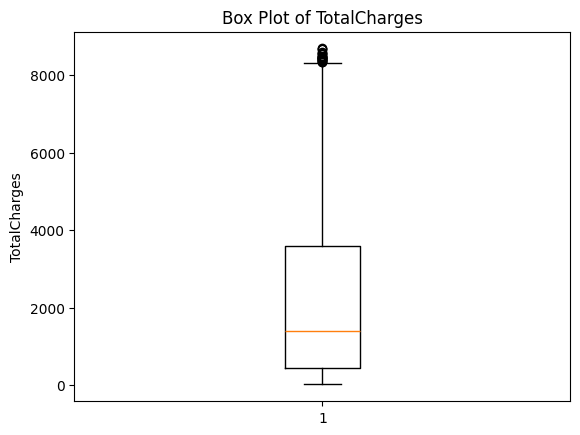

In [126]:
plt.boxplot(data['TotalCharges'])
plt.ylabel("TotalCharges")
plt.title("Box Plot of TotalCharges")
plt.show()

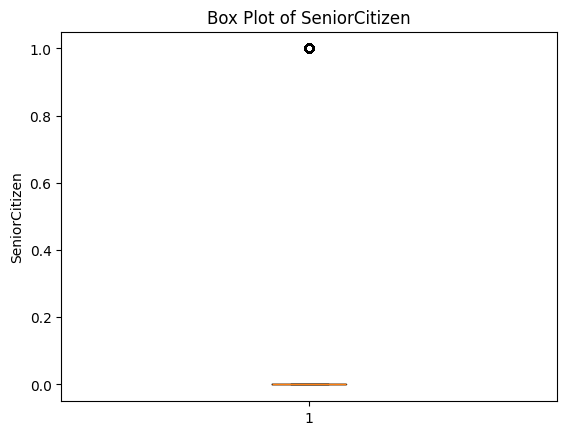

In [127]:
plt.boxplot(data['SeniorCitizen'])
plt.ylabel("SeniorCitizen")
plt.title("Box Plot of SeniorCitizen")
plt.show()

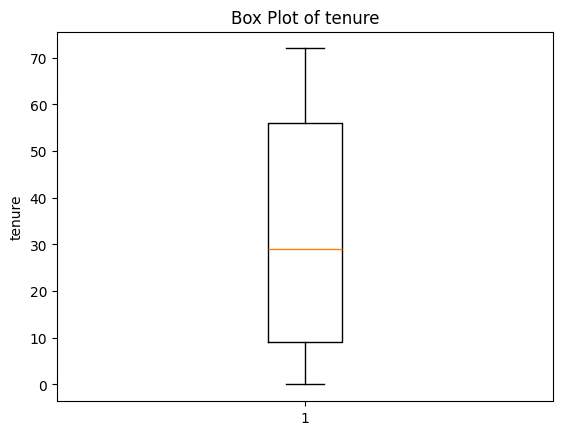

In [128]:
plt.boxplot(data['tenure'])
plt.ylabel("tenure")
plt.title("Box Plot of tenure")
plt.show()

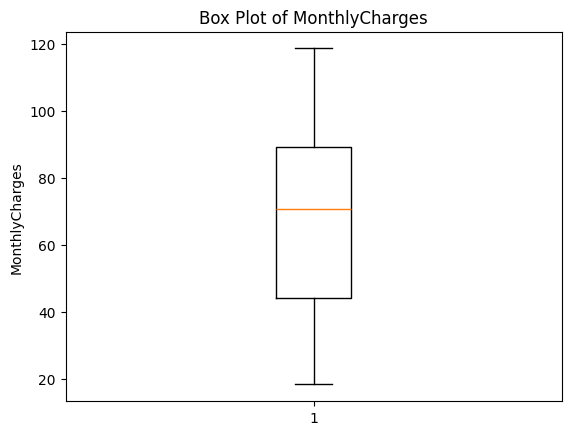

In [129]:
plt.boxplot(data['MonthlyCharges'])
plt.ylabel("MonthlyCharges")
plt.title("Box Plot of MonthlyCharges")
plt.show()

In [130]:
data = pd.get_dummies(data, columns=[
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
], drop_first=True)

In [131]:
data['Churn'] = data['Churn'].map({'No': 0, 'Yes': 1})

In [132]:
data[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,5626.000000,5626.000000,5626.000000
mean,32.651795,65.540242,2241.561002
std,24.603576,29.004061,2216.241011
min,0.000000,18.250000,18.850000
25%,9.000000,44.050000,450.500000
50%,29.000000,70.700000,1399.825000
75%,56.000000,89.137500,3601.037500
max,72.000000,118.750000,8684.800000


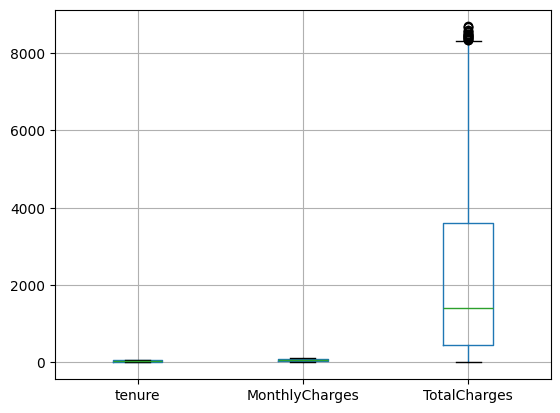

In [133]:
import matplotlib.pyplot as plt

data[['tenure', 'MonthlyCharges', 'TotalCharges']].boxplot()
plt.show()

In [134]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.fit_transform(
    X_train[['tenure', 'MonthlyCharges', 'TotalCharges']]
)

X_test[['tenure', 'MonthlyCharges', 'TotalCharges']] = scaler.transform(
    X_test[['tenure', 'MonthlyCharges', 'TotalCharges']]
)

In [135]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [136]:
data['Churn'].value_counts()

,count
Churn,
0,4127
1,1499


In [137]:
data['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
0,73.355848
1,26.644152


In [138]:
data['CustomerLifetimeValue'] = data['tenure'] * data['MonthlyCharges']

In [139]:
data['Tenure_OneYear'] = data['tenure'] * data['Contract_One year']
data['Tenure_TwoYear'] = data['tenure'] * data['Contract_Two year']

In [140]:
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
4337,Female,0,Yes,No,51,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.50,1281.25
2218,Female,0,Yes,Yes,62,Yes,Yes,DSL,No,No,No,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),70.45,4300.45
2333,Female,0,No,No,60,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.60,1093.00
1699,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,No,Bank transfer (automatic),69.70,69.70
3412,Male,0,No,No,20,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,No,Month-to-month,Yes,Electronic check,88.70,1761.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5185,Female,0,Yes,No,20,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,20.00,416.45
4730,Female,0,No,No,46,Yes,Yes,DSL,Yes,No,Yes,No,Yes,Yes,Two year,No,Mailed check,79.20,3593.80
922,Male,0,No,Yes,12,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.35,212.30
3149,Female,0,Yes,Yes,21,Yes,No,Fiber optic,No,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),74.05,1565.70


In [141]:
import numpy as np

conditions = [
    data['Contract_One year'] == 1,
    data['Contract_Two year'] == 1
]
choices = [1, 2]

data['ContractType'] = np.select(conditions, choices, default=0)

In [142]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Redefine X and y after all preprocessing steps, including one-hot encoding
X = data.drop('Churn', axis=1)
y = data['Churn']

# Re-run train_test_split after X and y are properly defined with numerical features
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Identify numerical columns for scaling
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Initialize StandardScaler
scaler = StandardScaler()

# Scale numerical features in X_train and X_test
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
model.fit(X_train, y_train)
y_pred = model.predict(X_test) # Corrected x_test to X_test
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.7939609236234458
[[735  91]
 [141 159]]


In [143]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86       826
           1       0.64      0.53      0.58       300

    accuracy                           0.79      1126
   macro avg       0.74      0.71      0.72      1126
weighted avg       0.78      0.79      0.79      1126



In [144]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.7939609236234458
[[735  91]
 [141 159]]


In [145]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81       826
           1       0.48      0.53      0.50       300

    accuracy                           0.72      1126
   macro avg       0.65      0.66      0.66      1126
weighted avg       0.73      0.72      0.73      1126



In [146]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.7939609236234458
[[735  91]
 [141 159]]


In [147]:
from sklearn.neighbors import KNeighborsClassifier

metric_k=[]
neighbors = np.arange(3,20)

for i in neighbors:
  knn_model = KNeighborsClassifier(n_neighbors=i)
  knn_model.fit(X_train,y_train)
  y_pred_knn = knn_model.predict(X_test)
  metric_k.append(accuracy_score(y_test,y_pred_knn))

In [148]:
knn_classifier = KNeighborsClassifier(n_neighbors=18)
knn_classifier.fit(X_train,y_train)
y_pred_knn = knn_classifier.predict(X_test)
print(accuracy_score(y_test,y_pred_knn))
print(confusion_matrix(y_test,y_pred_knn))

0.7904085257548845
[[724 102]
 [134 166]]


In [149]:
print(rf_model)

RandomForestClassifier(random_state=42)


In [150]:
rf_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [198]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
param_grid = {'C':[0.1,1,10,100],'gamma':[1,0.1,0.01,0.001]}
grid = GridSearchCV(SVC(),param_grid,refit=True,verbose=2)
grid.fit(X_train,y_train)
grid_predictions = grid.predict(X_test)
print('Accuracy Score:')
print(accuracy_score(y_test,grid_predictions))
print('Confusion Matrix:')
print(confusion_matrix(y_test,grid_predictions))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .....................................C=0.1, gamma=1; total time=   0.9s
[CV] END .....................................C=0.1, gamma=1; total time=   0.8s
[CV] END .....................................C=0.1, gamma=1; total time=   0.8s
[CV] END .....................................C=0.1, gamma=1; total time=   0.8s
[CV] END .....................................C=0.1, gamma=1; total time=   0.8s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.4s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.5s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.8s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.8s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.8s
[CV] END ..................................C=0.1, gamma=0.01; total time=   0.8s
[CV] END ..................................C=0.1

In [172]:
df=pd.read_csv("/content/drive/MyDrive/DSA/Case study/Testing_data.csv")

In [197]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,AvgMonthlySpend,TotalServices
0,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,81.20,3292.30,No,Medium,82.307500,1
1,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,No,...,Yes,One year,No,Electronic check,78.85,876.75,No,New,73.062500,4
2,Male,0,No,No,43,Yes,Yes,Fiber optic,No,No,...,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes,Medium,97.943023,3
3,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,Two year,Yes,Electronic check,118.20,8547.15,No,Long,118.710417,6
4,Female,0,No,No,10,No,No phone service,DSL,No,Yes,...,No,Month-to-month,No,Electronic check,36.25,374.00,No,New,37.400000,2


In [196]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [155]:
df.duplicated().sum()


np.int64(0)

In [175]:
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(
        df["TotalCharges"],
        errors="coerce"
    )

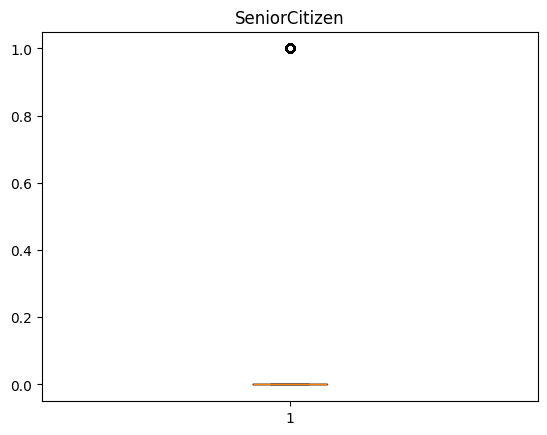

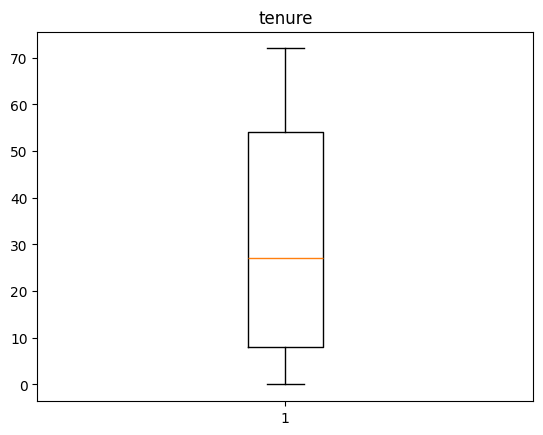

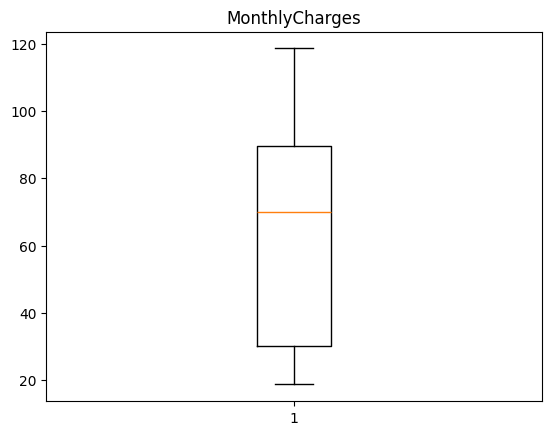

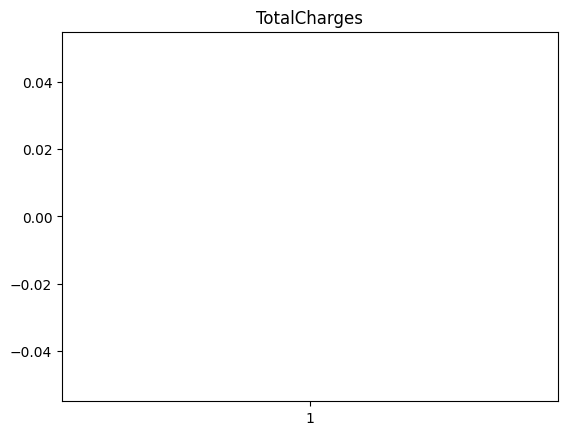

In [157]:
columns = df.select_dtypes(include=['number']).columns
for i in columns:
  plt.boxplot(df[i])
  plt.title(i)
  plt.show()

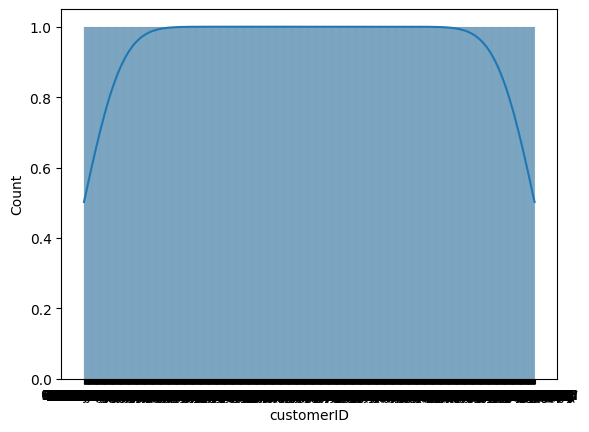

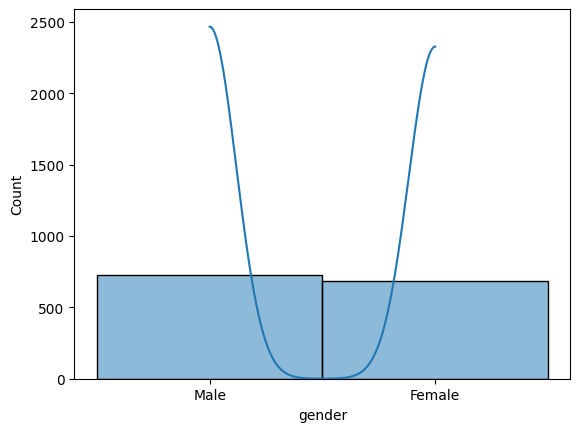

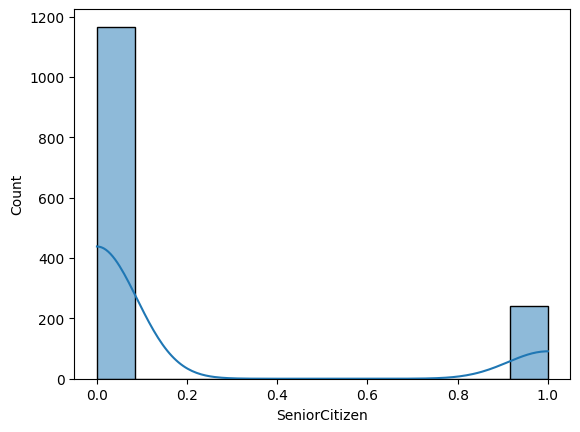

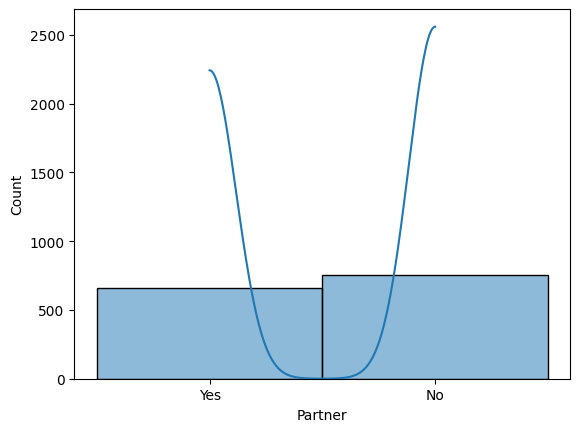

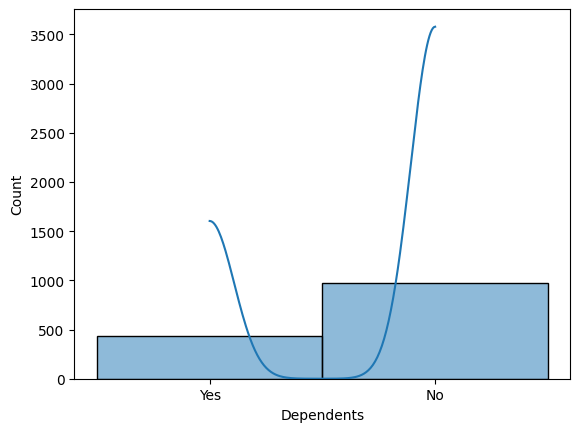

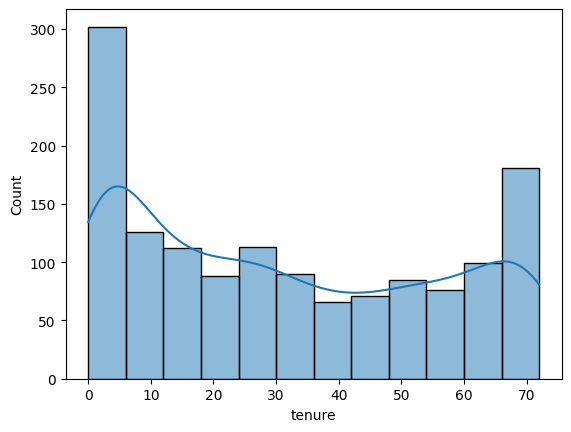

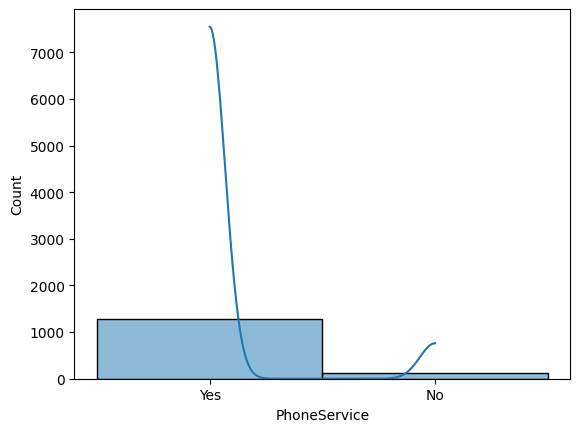

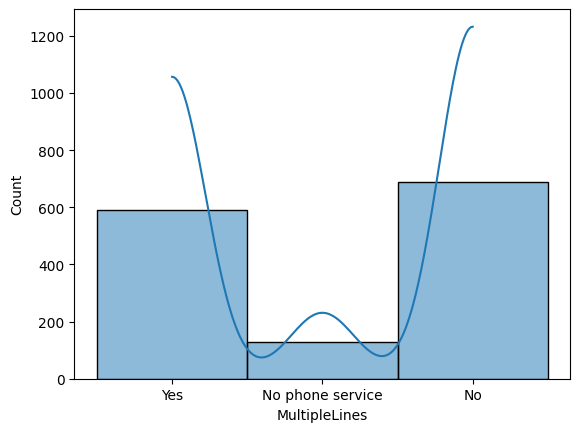

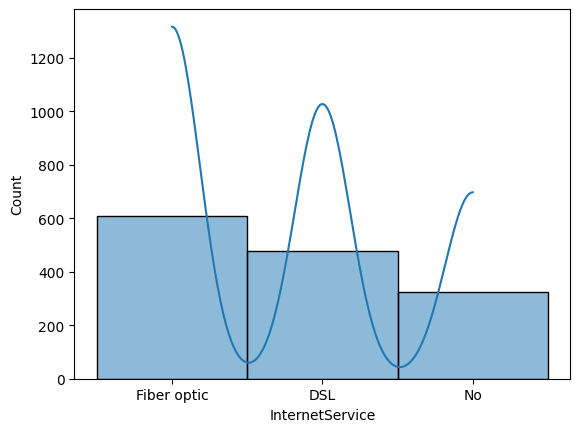

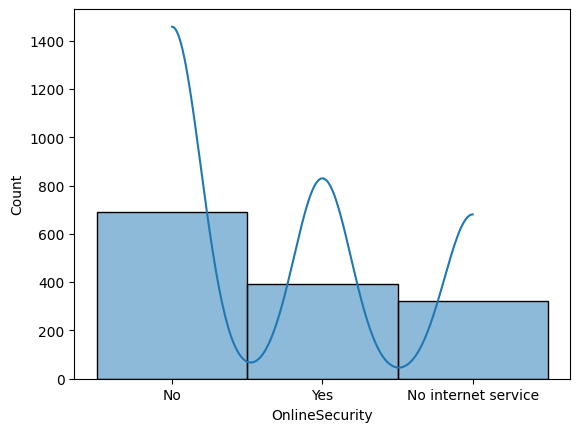

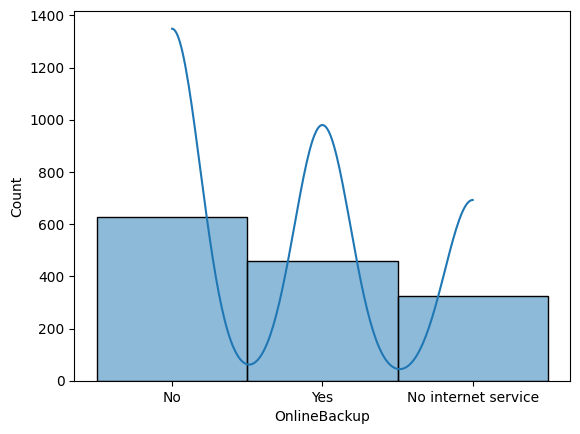

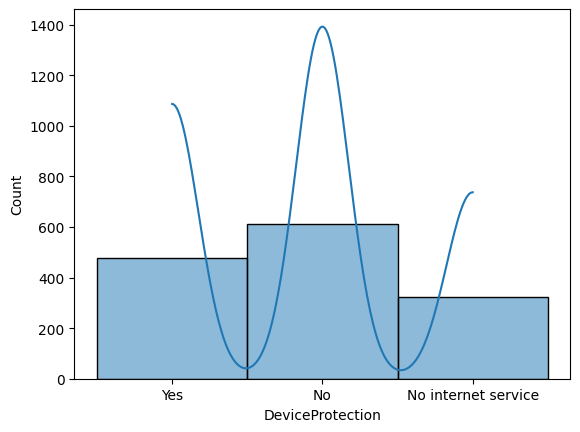

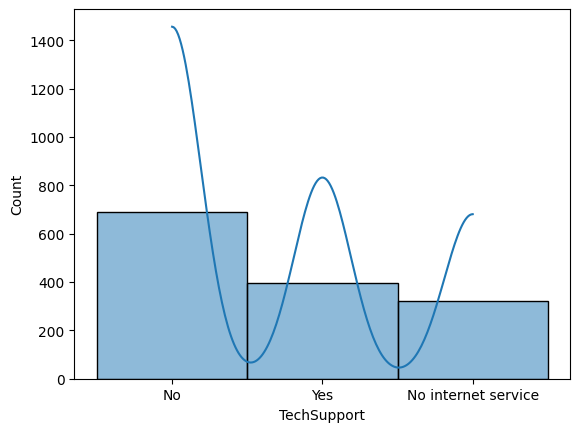

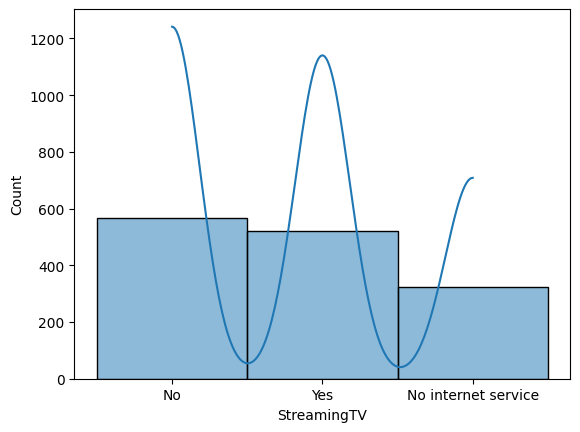

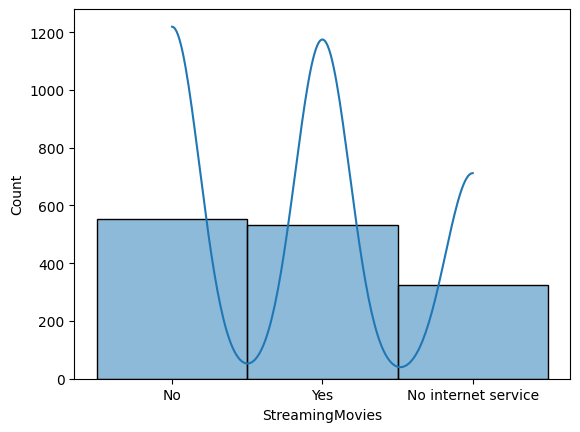

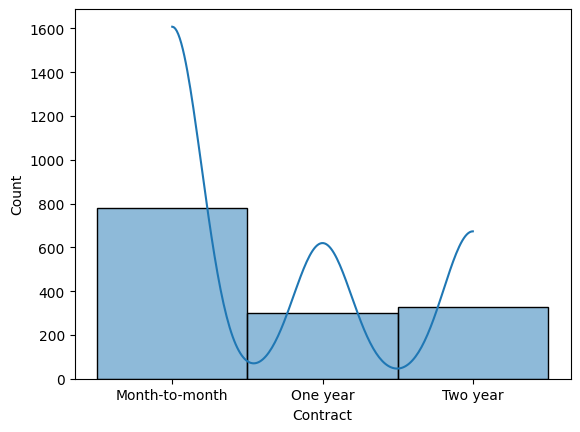

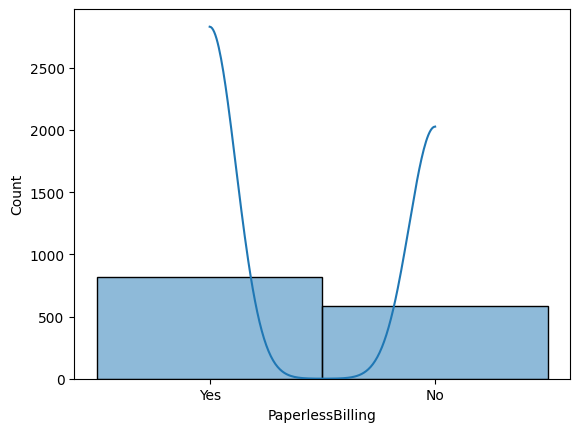

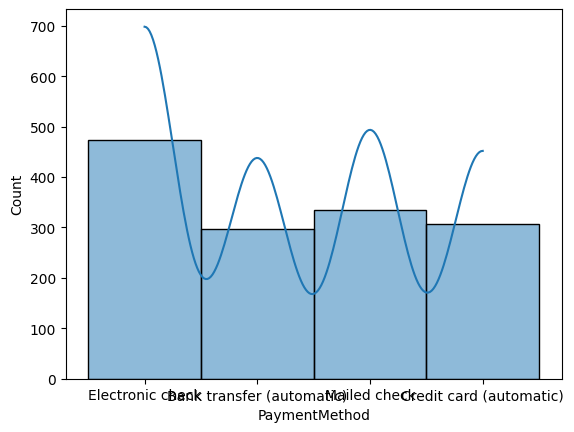

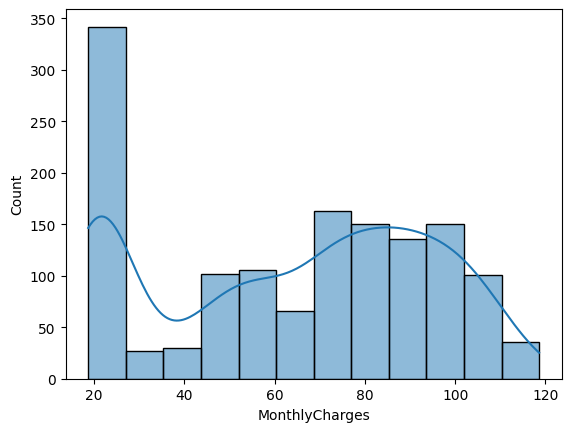

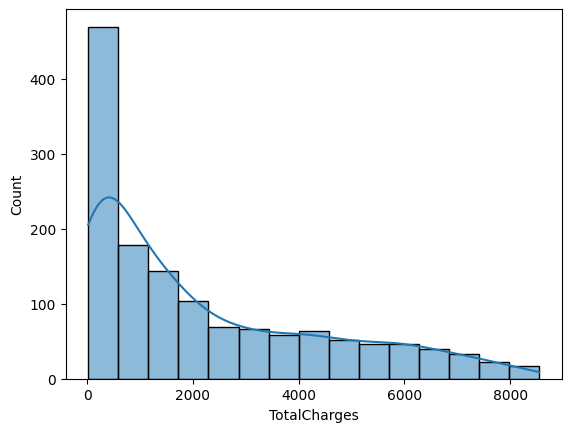

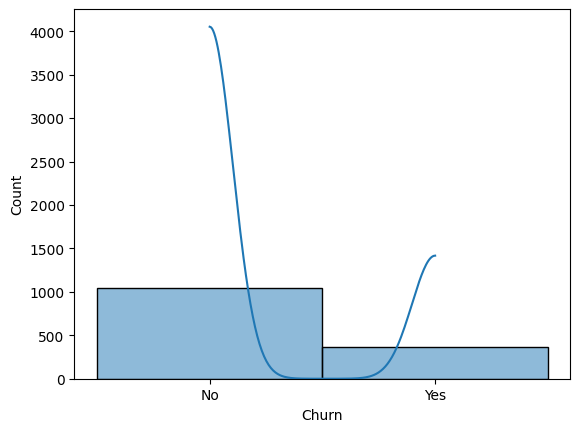

In [159]:
for i in df.columns:
  sns.histplot(df[i],kde=True)
  plt.show()

In [164]:
df = pd.get_dummies(
    df,
    columns=['MultipleLines',
             'InternetService',
             'OnlineSecurity',
             'OnlineBackup',
             'DeviceProtection',
             'TechSupport',
             'StreamingTV',
             'StreamingMovies',
             'Contract',
             'PaymentMethod'],
    drop_first=True
)

In [166]:
binary_cols = [
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [176]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['New', 'Short', 'Medium', 'Long']
)

In [178]:
df['AvgMonthlySpend'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

In [180]:
service_cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df['TotalServices'] = (
    df[service_cols] == 'Yes'
).sum(axis=1)

In [189]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# Identify numerical columns for scaling
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Apply fit_transform to the numerical columns of X_train
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

# Apply transform to the numerical columns of X_test
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [193]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
best_features = SelectKBest(score_func=chi2, k=10)
fit = best_features.fit(X_test, y_test)

In [203]:
model = LogisticRegression()
model.fit(X_test,y_test)
y_pred = model.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.8019538188277087
[[739  87]
 [136 164]]
